In [1]:
from utils.connector import postgres

def query(sql, params=None):
    with postgres() as pg:
        return pg.query(sql, params)

# Analiza relacji w activities dla IC50

In [2]:
sql_chembl_relations = """SELECT relation, COUNT(*)
FROM public.activities
WHERE standard_type = 'IC50'
GROUP BY relation;"""

data_relations = query(sql_chembl_relations)

data_relations.info()

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   relation  15 non-null     object
 1   count     16 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 388.0+ bytes


In [3]:
print(data_relations)

print(data_relations.sort_values(by='count', ascending=False))

print("Unikalne relacje:")
print(data_relations['relation'].unique())

    relation    count
0          -        3
1         --       10
2          <   176667
3         <<        5
4         <=     8227
5          =  2593063
6        =~~        1
7          >   527185
8         >=     7114
9         >>      247
10       >>>        4
11         ~      601
12        ~~        6
13  &amp;gt;     2430
14  &amp;lt;        2
15      None   237300
    relation    count
5          =  2593063
7          >   527185
15      None   237300
2          <   176667
4         <=     8227
8         >=     7114
13  &amp;gt;     2430
11         ~      601
9         >>      247
1         --       10
12        ~~        6
3         <<        5
10       >>>        4
0          -        3
14  &amp;lt;        2
6        =~~        1
Unikalne relacje:
['-' '--' '<' '<<' '<=' '=' '=~~' '>' '>=' '>>' '>>>' '~' '~~' '&amp;gt;'
 '&amp;lt;' None]


# Analiza jednostek

In [4]:
sql_chembl_ic50_units_human = """select * from chembl_ic50_units_human"""

data_units = query(sql_chembl_ic50_units_human)

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


Dane jednostek IC50 (ludzki, exact):
  standard_units  n_records     min_value     max_value    mean_value  \
0             nM    1584674  1.427000e-13  7.943282e+22  5.012567e+16   
1        ug.mL-1      22305  1.000000e-08  2.850000e+08  4.357987e+04   
2           None        159  2.000000e-03  2.020000e+03  2.987534e+01   
3             ug        136  5.000000e-03  3.000000e+02  4.029931e+01   
4        10^2 uM        114  7.000000e-02  1.320000e+01  2.033596e+00   

   median_value  
0        600.00  
1          5.81  
2          1.60  
3          1.95  
4          1.00  


/tmp/ipykernel_4999/1859414622.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='standard_units', y='n_records', data=data_units_sorted, palette='viridis')


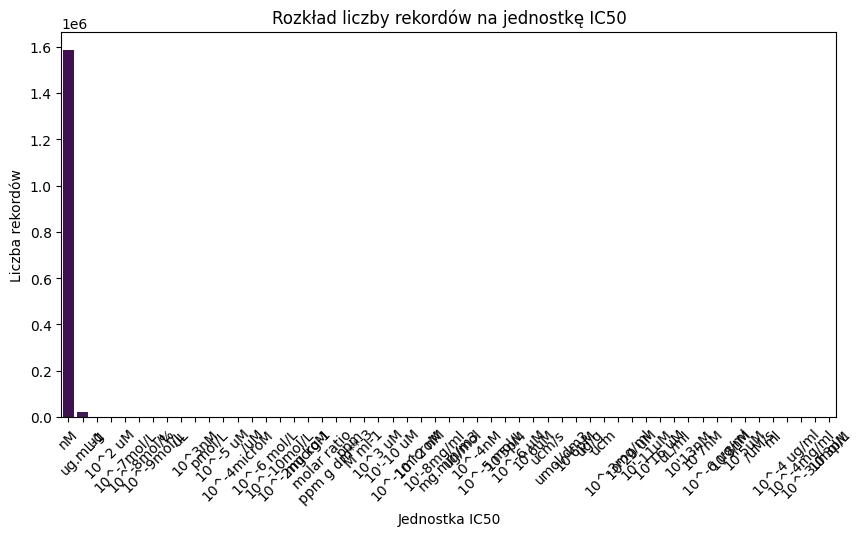

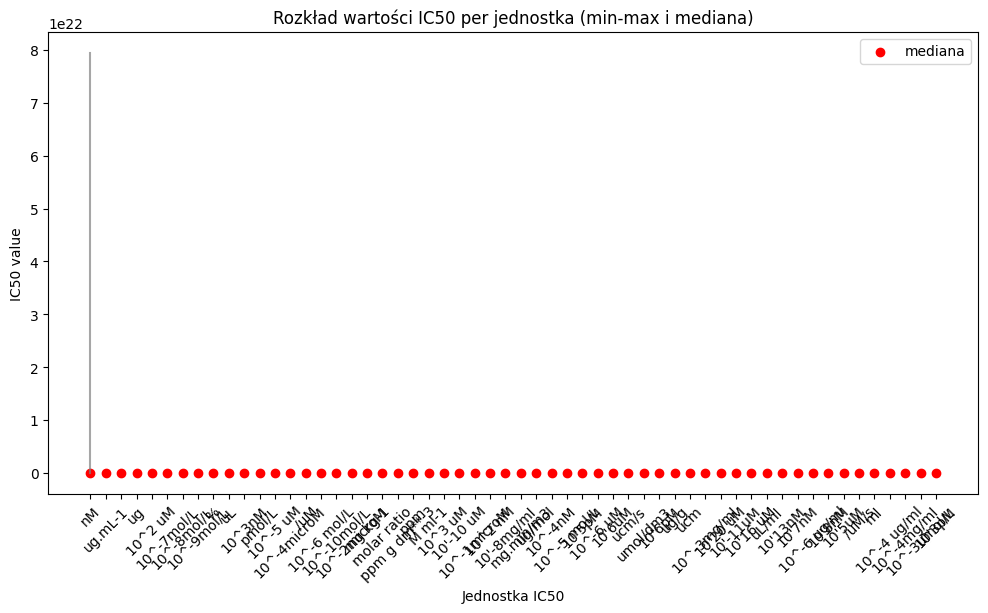

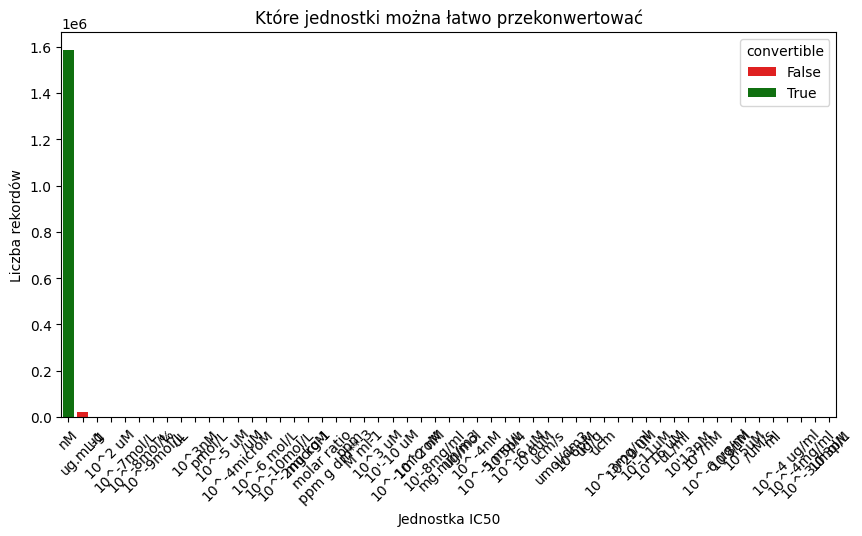

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Dane jednostek IC50 (ludzki, exact):")
print(data_units.head())

data_units_sorted = data_units.sort_values('n_records', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='standard_units', y='n_records', data=data_units_sorted, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Liczba rekordów")
plt.xlabel("Jednostka IC50")
plt.title("Rozkład liczby rekordów na jednostkę IC50")
plt.show()

plt.figure(figsize=(12,6))
for idx, row in data_units_sorted.iterrows():
    plt.plot([idx, idx], [row['min_value'], row['max_value']], color='gray', alpha=0.7)  # type: ignore # linia min-max
    plt.scatter(idx, row['median_value'], color='red', label='mediana' if idx==0 else "")  # type: ignore # mediana
plt.xticks(range(len(data_units_sorted)), data_units_sorted['standard_units'], rotation=45) # type: ignore
plt.ylabel("IC50 value")
plt.xlabel("Jednostka IC50")
plt.title("Rozkład wartości IC50 per jednostka (min-max i mediana)")
plt.legend()
plt.show()

data_units_sorted['convertible'] = data_units_sorted['standard_units'].isin(['pM','nM','uM','mM'])

plt.figure(figsize=(10,5))
sns.barplot(x='standard_units', y='n_records', hue='convertible', data=data_units_sorted, palette=['red','green'])
plt.xticks(rotation=45)
plt.ylabel("Liczba rekordów")
plt.xlabel("Jednostka IC50")
plt.title("Które jednostki można łatwo przekonwertować")
plt.show()


# Lista wszystkich jednostek

In [6]:
data_units_sorted

,standard_units,n_records,min_value,max_value,mean_value,median_value,convertible
0,nM,1584674,1.427000e-13,7.943282e+22,5.012567e+16,600.000000,True
1,ug.mL-1,22305,1.000000e-08,2.850000e+08,4.357987e+04,5.810000,False
2,None,159,2.000000e-03,2.020000e+03,2.987534e+01,1.600000,False
3,ug,136,5.000000e-03,3.000000e+02,4.029931e+01,1.950000,False
4,10^2 uM,114,7.000000e-02,1.320000e+01,2.033596e+00,1.000000,False
5,10^-7mol/L,74,1.000000e+00,9.330000e+00,2.685676e+00,2.105000,False
6,10^-8mol/L,60,1.100000e+00,9.800000e+00,4.851333e+00,4.000000,False
7,10^-9mol/L,55,1.110000e+00,9.800000e+00,5.272000e+00,5.700000,False
8,%,41,9.000000e-02,9.500000e+01,4.987780e+01,39.000000,False
9,uL,20,2.900000e+00,2.900000e+00,2.900000e+00,2.900000,False


# Statystyki zmiennej docelowej

Statystyki już zostały przeprowadzone na zlogarytmowanej wartości

In [7]:
sql = """select * from chembl_pic50_compounds;"""

data = query(sql)

print(f"Compounds: {len(data)}")
print(f"Median assays / compound: {data['n_assays'].median():.1f}")
print(f"pIC50 range: {data['pIC50_median'].min():.2f} – {data['pIC50_median'].max():.2f}")
print(data.columns)

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


Compounds: 663139
Median assays / compound: 1.0
pIC50 range: 2.16 – 11.00
Index(['canonical_smiles', 'n_assays', 'pIC50_mean', 'pIC50_median',
       'pIC50_min', 'pIC50_max'],
      dtype='object')


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663139 entries, 0 to 663138
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   canonical_smiles  663139 non-null  object 
 1   n_assays          663139 non-null  int64  
 2   pIC50_mean        663139 non-null  float64
 3   pIC50_median      663139 non-null  float64
 4   pIC50_min         663139 non-null  float64
 5   pIC50_max         663139 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 30.4+ MB


In [9]:
data.describe()

,n_assays,pIC50_mean,pIC50_median,pIC50_min,pIC50_max
count,663139.000000,663139.000000,663139.000000,663139.000000,663139.000000
mean,2.300457,6.508537,6.509079,6.274137,6.744708
std,13.181279,1.289610,1.307675,1.339376,1.369354
min,1.000000,2.162412,2.162412,2.045757,2.162412
25%,1.000000,5.477556,5.451127,5.173925,5.643974
50%,1.000000,6.490014,6.481486,6.199998,6.756962
75%,2.000000,7.423659,7.453457,7.259637,7.749580
max,5467.000000,11.000000,11.000000,11.000000,11.000000


## Histogram median pIC50

Im wyższa wartość pIC50, tym bardziej aktywny związek.

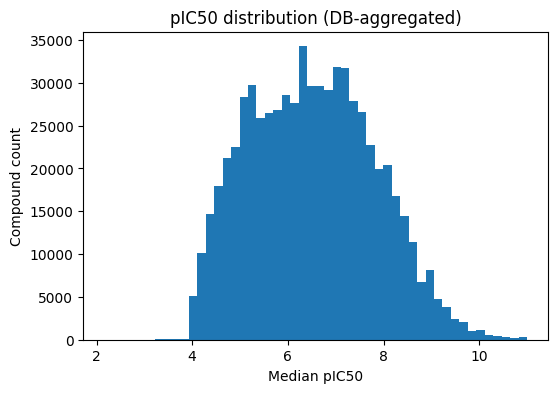

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data['pIC50_median'], bins=50)
plt.xlabel("Median pIC50")
plt.ylabel("Compound count")
plt.title("pIC50 distribution (DB-aggregated)")
plt.show()

## Zmienność aktywności w obrębie każdego związku

- pIC50_range - rorzut aktywności danego związku
- Mały zakres - wszystkie assay są zbliżone, związek wydaje się stabilny
- Duży zakres - możliwe błędy pomiarowe, różne warunki eksperymentalne lub związek zachowuje się niestabilnie.

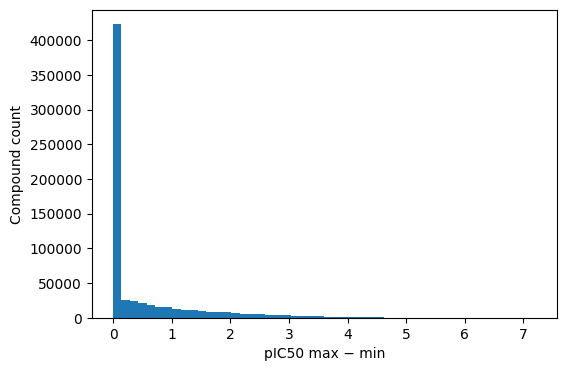

In [11]:
data['pIC50_range'] = data['pIC50_max'] - data['pIC50_min']

plt.figure(figsize=(6,4))
plt.hist(data['pIC50_range'], bins=50)
plt.xlabel("pIC50 max − min")
plt.ylabel("Compound count")
plt.show()

## Ile procent związków ma niepewne (rozbieżne) wartości pIC50 ?

In [12]:
data['noisy'] = data['pIC50_range'] > 1.0
print(f"Noisy compounds: {data['noisy'].mean()*100:.1f}%")

Noisy compounds: 18.0%


## Liczba assayów na związek


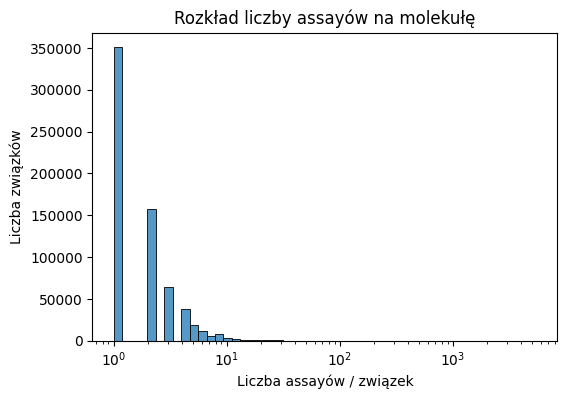

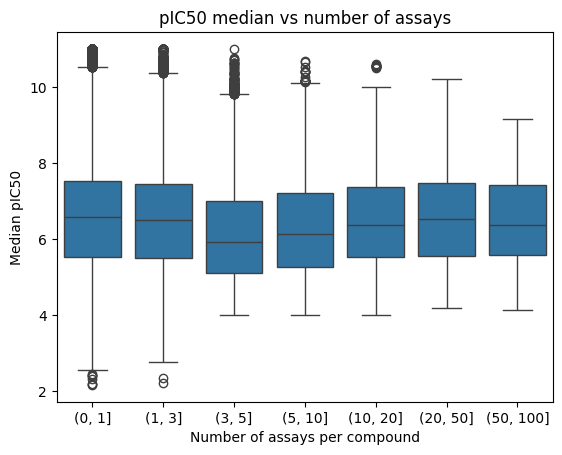

In [13]:
import seaborn as sns
import pandas as pd

plt.figure(figsize=(6,4))
sns.histplot(data['n_assays'], bins=50, log_scale=(True, False)) # type: ignore
plt.xlabel("Liczba assayów / związek")
plt.ylabel("Liczba związków")
plt.title("Rozkład liczby assayów na molekułę")
plt.show()

sns.boxplot(x=pd.cut(data['n_assays'], bins=[0,1,3,5,10,20,50,100]), y=data['pIC50_median'])
plt.xlabel("Number of assays per compound")
plt.ylabel("Median pIC50")
plt.title("pIC50 median vs number of assays")
plt.show()

## Korelacje między statystykami


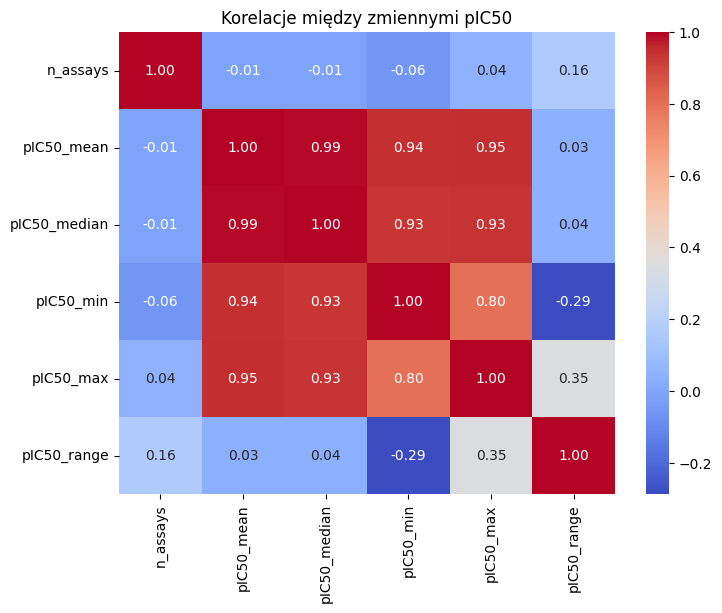

In [14]:
corr = data[['n_assays', 'pIC50_mean', 'pIC50_median', 'pIC50_min', 'pIC50_max', 'pIC50_range']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Korelacje między zmiennymi pIC50")
plt.show()

## Analiza noisy compounds

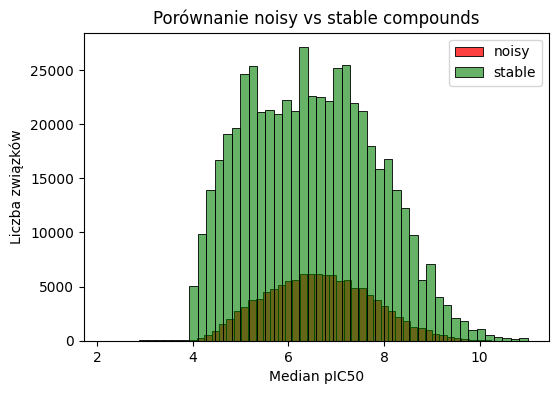

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(data[data['noisy']==True]['pIC50_median'], bins=50, color='red', label='noisy') # type: ignore
sns.histplot(data[data['noisy']==False]['pIC50_median'], bins=50, color='green', label='stable', alpha=0.6) # type: ignore
plt.xlabel("Median pIC50")
plt.ylabel("Liczba związków")
plt.title("Porównanie noisy vs stable compounds")
plt.legend()
plt.show()

## Wylistowanie związków stabilnych i szumnych

In [16]:
stable = (
    data[data['noisy'] == False]
    .sort_values(by=['pIC50_range', 'n_assays'], ascending=[True, False])
)

stable.head(10)

,canonical_smiles,n_assays,pIC50_mean,pIC50_median,pIC50_min,pIC50_max,pIC50_range,noisy
346109,CN1C(=O)[C@@H](N2CCc3cn(CC4CCS(=O)(=O)CC4)nc3C...,337,6.000000,6.000000,6.000000,6.000000,0.0,False
5720,c1cn2cc(-c3ccc4ncn(C5CCCCC5)c4c3)nc(-c3ccc4ncn...,60,6.091515,6.091515,6.091515,6.091515,0.0,False
62282,Cc1ccc(S(=O)(=O)O)cc1.Cc1ccc(S(=O)(=O)[O-])cc1...,39,6.148742,6.148742,6.148742,6.148742,0.0,False
335976,CN1CCN(c2ccc3nc(-c4ccc(OCCCN5C(=O)c6cccc7cccc(...,21,6.958607,6.958607,6.958607,6.958607,0.0,False
467193,COc1cc(OC)c(F)c(N2Cc3cnc(-c4cncc(NS(C)(=O)=O)c...,21,6.939302,6.939302,6.939302,6.939302,0.0,False
564303,O=C1c2cccc3cccc(c23)C(=O)N1CCCCOc1ccc(-c2nc3cc...,21,6.958607,6.958607,6.958607,6.958607,0.0,False
147788,CC(C)=CCC[C@]1(C)C=Cc2c(c(C)cc3c2[nH]c2ccccc23)O1,19,4.602060,4.602060,4.602060,4.602060,0.0,False
154778,CC(C)=CCC[C@H]1C=Cc2c(c(C)cc3c2[nH]c2cc(O)ccc2...,19,5.154902,5.154902,5.154902,5.154902,0.0,False
225093,C=CC(=O)Nc1cc(-c2cc3c(cn2)CN(c2c(F)c(OC)cc(OC)...,18,6.939302,6.939302,6.939302,6.939302,0.0,False
228854,C=CC(=O)Nc1cncc(-c2cc3c(cn2)CN(c2c(F)c(OC)cc(O...,18,6.939302,6.939302,6.939302,6.939302,0.0,False


In [17]:
data.loc[346109]
print(data.loc[346109][0])

CN1C(=O)[C@@H](N2CCc3cn(CC4CCS(=O)(=O)CC4)nc3C2=O)COc2ccccc21


/tmp/ipykernel_4999/1104431435.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(data.loc[346109][0])


In [18]:
very_stable = data[
    (data['pIC50_range'] < 0.5) &
    (data['n_assays'] >= 3)
].sort_values(by='pIC50_range')

very_stable.head(10)

,canonical_smiles,n_assays,pIC50_mean,pIC50_median,pIC50_min,pIC50_max,pIC50_range,noisy
401256,COc1ccc2[nH]c(-c3cc(OC)c4ncnn4c3)c(C(C)C)c2n1,6,7.337242,7.337242,7.337242,7.337242,0.0,False
517720,Nc1ccc(-c2cccnc2)cc1NC(=O)c1cnc(N2CCNCC2)s1,4,6.593460,6.593460,6.593460,6.593460,0.0,False
517857,Nc1ccc(-c2cccs2)cc1NC(=O)NC1COC1,3,4.755723,4.755723,4.755723,4.755723,0.0,False
517902,Nc1ccc(-c2ccncc2)cc1NC(=O)c1cnc(N2CCNCC2)cn1,4,6.593460,6.593460,6.593460,6.593460,0.0,False
517935,Nc1ccc(-c2ccoc2)cc1NC(=O)c1nc(N2CCNCC2)cs1,3,6.593460,6.593460,6.593460,6.593460,0.0,False
518097,Nc1ccc(-c2nc3ccncc3n2-c2ccc(Cl)cc2)cn1,4,6.154902,6.154902,6.154902,6.154902,0.0,False
518098,Nc1ccc(-c2nc3ccncc3n2-c2ccc(Cl)cc2F)cn1,4,6.154902,6.154902,6.154902,6.154902,0.0,False
267517,CCN(CC)CC#CCOC(=O)C(O)(c1ccccc1)C1CCCCC1,3,4.562249,4.562249,4.562249,4.562249,0.0,False
401716,COc1ccc2[nH]c(SCc3ccc(C(=O)O)cc3)nc2c1,8,4.301030,4.301030,4.301030,4.301030,0.0,False
401783,COc1cc(-c2nn3c(c2C(N)=O)NCCC3c2ccccc2NC(=O)/C=...,3,8.795880,8.795880,8.795880,8.795880,0.0,False


In [19]:
noisy_compounds = (
    data
    .sort_values(by=['pIC50_range', 'n_assays'], ascending=[False, False])
)

noisy_compounds.head(10)

,canonical_smiles,n_assays,pIC50_mean,pIC50_median,pIC50_min,pIC50_max,pIC50_range,noisy
573709,Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1,214,4.882159,4.605910,3.436519,10.647817,7.211299,True
129536,CC[C@]1(O)C[C@H]2CN(CCc3c([nH]c4ccccc34)[C@@](...,301,7.345403,7.522879,4.000000,11.000000,7.000000,True
520946,Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)C2(F)F)c(=O)n1,967,6.908440,6.916748,4.000000,10.982132,6.982132,True
116096,CCc1c2c(nc3ccc(OC(=O)N4CCC(N5CCCCC5)CC4)cc13)-...,220,5.590343,5.284530,4.044553,11.000000,6.955447,True
313565,CC(=O)O[C@H]1C(=O)[C@@]2(C)[C@H]([C@H](OC(=O)c...,2780,7.315124,7.675512,4.045757,11.000000,6.954243,True
421656,COc1ccc(/C=C\c2cc(OC)c(OC)c(OC)c2)cc1O,1388,7.527665,7.958607,4.077482,11.000000,6.922518,True
103303,Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C...,439,6.491997,6.299054,4.029773,10.883060,6.853287,True
652736,O=C(OCCS(=O)(=O)c1ccccc1)N1c2ccccc2[C@@]23O[C@...,10,6.416002,6.107905,4.200659,11.000000,6.799341,True
7189,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...,128,8.498431,8.769551,4.221849,11.000000,6.778151,True
448905,COc1ccc(N(C(=O)Oc2c(C)cccc2C)c2ccnc(Nc3ccc(N4C...,174,5.514310,5.239344,4.025336,10.788879,6.763543,True


In [20]:
noisy_compounds.loc[573709]
print(noisy_compounds.loc[573709][0])

Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1


/tmp/ipykernel_4999/4039892837.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(noisy_compounds.loc[573709][0])


In [21]:
data[data['noisy'] == True] \
    .sort_values(by='pIC50_range', ascending=False) \
    .head(10)

,canonical_smiles,n_assays,pIC50_mean,pIC50_median,pIC50_min,pIC50_max,pIC50_range,noisy
573709,Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1,214,4.882159,4.605910,3.436519,10.647817,7.211299,True
129536,CC[C@]1(O)C[C@H]2CN(CCc3c([nH]c4ccccc34)[C@@](...,301,7.345403,7.522879,4.000000,11.000000,7.000000,True
520946,Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)C2(F)F)c(=O)n1,967,6.908440,6.916748,4.000000,10.982132,6.982132,True
116096,CCc1c2c(nc3ccc(OC(=O)N4CCC(N5CCCCC5)CC4)cc13)-...,220,5.590343,5.284530,4.044553,11.000000,6.955447,True
313565,CC(=O)O[C@H]1C(=O)[C@@]2(C)[C@H]([C@H](OC(=O)c...,2780,7.315124,7.675512,4.045757,11.000000,6.954243,True
421656,COc1ccc(/C=C\c2cc(OC)c(OC)c(OC)c2)cc1O,1388,7.527665,7.958607,4.077482,11.000000,6.922518,True
103303,Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(C...,439,6.491997,6.299054,4.029773,10.883060,6.853287,True
652736,O=C(OCCS(=O)(=O)c1ccccc1)N1c2ccccc2[C@@]23O[C@...,10,6.416002,6.107905,4.200659,11.000000,6.799341,True
7189,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...,128,8.498431,8.769551,4.221849,11.000000,6.778151,True
448905,COc1ccc(N(C(=O)Oc2c(C)cccc2C)c2ccnc(Nc3ccc(N4C...,174,5.514310,5.239344,4.025336,10.788879,6.763543,True


## Analiza zależności między medianą a rozrzutem

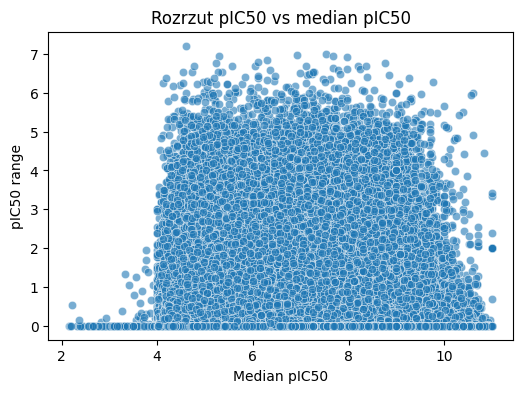

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='pIC50_median', y='pIC50_range', data=data, alpha=0.6)
plt.xlabel("Median pIC50")
plt.ylabel("pIC50 range")
plt.title("Rozrzut pIC50 vs median pIC50")
plt.show()

## Cechy molekularne a cechy atomowe / Test środowiska rdkit

cechy molekularne - opisują całą cząsteczke jako całość,
cechy atomowe - opisują pojedyncze atomowy lub ich lokalne środowisko w cząsteczce. 

### Deskryptory molekularne

In [23]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, QED

smiles = "CC(=O)Oc1ccccc1C(=O)O"  # Aspiryna
mol = Chem.MolFromSmiles(smiles)

# deskryptory molekularne
mol_weight = Descriptors.MolWt(mol) # type: ignore
logp = Descriptors.MolLogP(mol) # type: ignore
psa = rdMolDescriptors.CalcTPSA(mol)
hba = rdMolDescriptors.CalcNumHBA(mol)
hbd = rdMolDescriptors.CalcNumHBD(mol)
rot_bonds = Descriptors.NumRotatableBonds(mol) # type: ignore
qed_score = QED.qed(mol)

# ładne wyświetlenie
molecular_features = {
    "Molecular Weight": mol_weight,
    "LogP": logp,
    "TPSA": psa,
    "HBA (H-bond Acceptors)": hba,
    "HBD (H-bond Donors)": hbd,
    "Rotatable Bonds": rot_bonds,
    "QED (Drug-likeness)": qed_score
}

print("Molecular features for Aspirin:")
for feature, value in molecular_features.items():
    print(f"{feature:25}: {value:.3f}")

Molecular features for Aspirin:
Molecular Weight         : 180.159
LogP                     : 1.310
TPSA                     : 63.600
HBA (H-bond Acceptors)   : 3.000
HBD (H-bond Donors)      : 1.000
Rotatable Bonds          : 2.000
QED (Drug-likeness)      : 0.550


### Deskryptory atomowe

In [24]:
atom_features = []

for atom in mol.GetAtoms():
    atom_features.append({
        "atom_idx": atom.GetIdx(),
        "symbol": atom.GetSymbol(),
        "atomic_num": atom.GetAtomicNum(),
        "hybridization": str(atom.GetHybridization()),
        "formal_charge": atom.GetFormalCharge(),
        "aromatic": atom.GetIsAromatic(),
        "num_implicit_H": atom.GetNumImplicitHs(),
        "degree": atom.GetDegree(),
        "total_valence": atom.GetTotalValence()
    })

print("Atom features:")
for feat in atom_features:
    print(feat)

Atom features:
{'atom_idx': 0, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP3', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 3, 'degree': 1, 'total_valence': 4}
{'atom_idx': 1, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 0, 'degree': 3, 'total_valence': 4}
{'atom_idx': 2, 'symbol': 'O', 'atomic_num': 8, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 0, 'degree': 1, 'total_valence': 2}
{'atom_idx': 3, 'symbol': 'O', 'atomic_num': 8, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': False, 'num_implicit_H': 0, 'degree': 2, 'total_valence': 2}
{'atom_idx': 4, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': True, 'num_implicit_H': 0, 'degree': 3, 'total_valence': 4}
{'atom_idx': 5, 'symbol': 'C', 'atomic_num': 6, 'hybridization': 'SP2', 'formal_charge': 0, 'aromatic': True, 'num_implicit_H': 1, 'degree': 2, 'total_valence': 

## pCI50 po konwersji

In [25]:
sql_chembl_ic50_all_units = """SELECT * FROM chembl_pic50_compounds_all_units"""

all_units_aggregated = query(sql_chembl_ic50_all_units)
all_units_aggregated.head()

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


,canonical_smiles,n_assays,pic50_mean,pic50_median,pic50_min,pic50_max,all_units
0,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...,5467,6.332208,6.301030,4.000000,10.327902,[nM]
1,O=C(CCCCCCC(=O)Nc1ccccc1)NO,3803,6.238839,6.079642,4.000000,9.677781,[nM]
2,CC(=O)O[C@H]1C(=O)[C@@]2(C)[C@H]([C@H](OC(=O)c...,2780,7.315124,7.675512,4.045757,11.000000,[nM]
3,O=c1[nH]cc(F)c(=O)[nH]1,2252,5.010481,4.946922,4.000000,8.397940,[nM]
4,COc1cc([C@@H]2c3cc4c(cc3[C@@H](O[C@@H]3O[C@@H]...,2071,5.551380,5.591760,4.000000,9.000000,[nM]


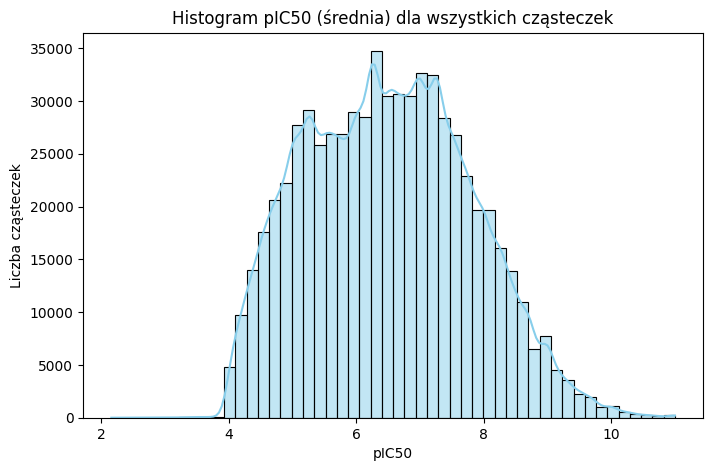

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(all_units_aggregated['pic50_mean'], bins=50, kde=True, color='skyblue') # type: ignore
plt.title("Histogram pIC50 (średnia) dla wszystkich cząsteczek")
plt.xlabel("pIC50")
plt.ylabel("Liczba cząsteczek")
plt.show()

## Przekonwertowane IC50

In [27]:

sql_chembl_ic50_converted = """SELECT * FROM chembl_ic50_all_converted"""

all_units = query(sql_chembl_ic50_converted)
all_units.head()

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


,activity_id,assay_id,molregno,canonical_smiles,standard_value,standard_units,standard_type,relation,pchembl_value,data_validity_comment,activity_comment,src_id,ic50_molar,pic50
0,15633342,1502983,1950519,CCN1C(=S)N2CCCC2c2c1nc(C(C)N1CCOCC1)[nH]c2=O,2670.0,nM,IC50,=,5.57,None,None,1,2.670000e-06,5.573489
1,15612757,1499475,1947287,COc1cc(/C=C/C(=O)OC[C@H]2O[C@H](O[C@]3(CO)O[C@...,17200.0,nM,IC50,=,4.76,None,None,1,1.720000e-05,4.764472
2,15623119,1500328,1949708,Cc1ccc(-n2nc(-c3cccnc3)cc2NC(=O)c2cnn3cccnc23)cc1,99.0,nM,IC50,=,7.00,None,None,1,9.900000e-08,7.004365
3,15672061,1508738,1956159,CC1CC2=C(CO1)C(=O)c1ccccc1C2=O,25300.0,nM,IC50,=,4.60,None,None,1,2.530000e-05,4.596879
4,15672092,1508741,1956159,CC1CC2=C(CO1)C(=O)c1ccccc1C2=O,23200.0,nM,IC50,=,4.63,None,None,1,2.320000e-05,4.634512


## Ile jednostek zostało po konwersji, które dało się łatwo przekonwertować?

In [28]:
total = len(all_units)

not_converted = all_units['ic50_molar'].isna().sum()
not_converted_pIC50 = all_units['pic50'].isna().sum()

print(f"Liczba wszystkich rekordów IC50: {total}")
print(f"Liczba rekordów bez ic50_molar (nieprzekonwertowane): {not_converted}")
print(f"Liczba rekordów bez pIC50 (nieprzekonwertowane): {not_converted_pIC50}")
print(f"Procent nieprzekonwertowanych (ic50_molar): {100*not_converted/total:.2f}%")
print(f"Procent nieprzekonwertowanych (pIC50): {100*not_converted_pIC50/total:.2f}%")

Liczba wszystkich rekordów IC50: 1545824
Liczba rekordów bez ic50_molar (nieprzekonwertowane): 20301
Liczba rekordów bez pIC50 (nieprzekonwertowane): 20301
Procent nieprzekonwertowanych (ic50_molar): 1.31%
Procent nieprzekonwertowanych (pIC50): 1.31%


## Statystyki na przekonwertowanym zbiorze

In [29]:
df_clean = all_units.dropna(subset=['ic50_molar', 'pic50'])

print(f"Liczba rekordów po usunięciu nieprzekonwertowanych: {len(df_clean)}")
print(f"Liczba unikalnych cząsteczek po oczyszczeniu: {df_clean['canonical_smiles'].nunique()}")

Liczba rekordów po usunięciu nieprzekonwertowanych: 1525523
Liczba unikalnych cząsteczek po oczyszczeniu: 663139


In [30]:
print(df_clean.info())
print(df_clean.describe())

print("Liczba unikalnych cząsteczek:", df_clean['canonical_smiles'].nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 1525523 entries, 0 to 1545823
Data columns (total 14 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   activity_id            1525523 non-null  int64  
 1   assay_id               1525523 non-null  int64  
 2   molregno               1525523 non-null  int64  
 3   canonical_smiles       1525523 non-null  object 
 4   standard_value         1525523 non-null  float64
 5   standard_units         1525523 non-null  object 
 6   standard_type          1525523 non-null  object 
 7   relation               1525523 non-null  object 
 8   pchembl_value          1525523 non-null  float64
 9   data_validity_comment  0 non-null        object 
 10  activity_comment       380345 non-null   object 
 11  src_id                 1525523 non-null  int64  
 12  ic50_molar             1525523 non-null  float64
 13  pic50                  1525523 non-null  float64
dtypes: float64(4), int64(4)

## Rozkład

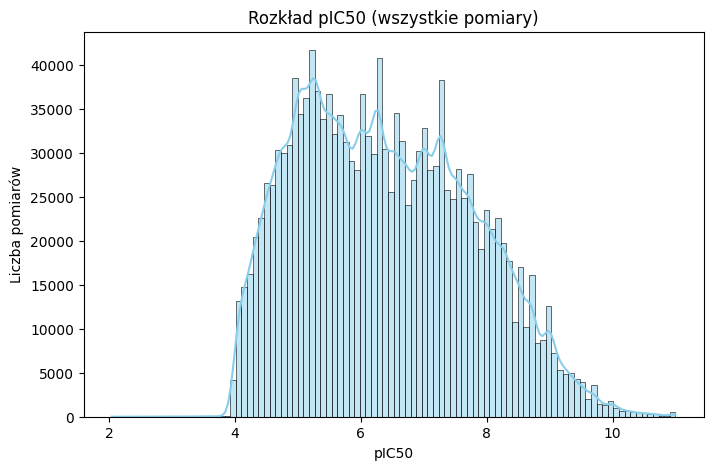

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_clean['pic50'], bins=100, kde=True, color='skyblue') # type: ignore
plt.title("Rozkład pIC50 (wszystkie pomiary)")
plt.xlabel("pIC50")
plt.ylabel("Liczba pomiarów")
plt.show()

## Połączenie zbioru z deskryptorami molekularnymi


In [32]:
sql_desc = "SELECT * FROM chembl_molecular_descriptors"
molecules = query(sql_desc)

df = df_clean.merge(molecules, on='canonical_smiles', how='left')

print(df.shape)

print(df.info())

print(df.isna().sum())

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


(1525921, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525921 entries, 0 to 1525920
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   activity_id            1525921 non-null  int64  
 1   assay_id               1525921 non-null  int64  
 2   molregno_x             1525921 non-null  int64  
 3   canonical_smiles       1525921 non-null  object 
 4   standard_value         1525921 non-null  float64
 5   standard_units         1525921 non-null  object 
 6   standard_type          1525921 non-null  object 
 7   relation               1525921 non-null  object 
 8   pchembl_value          1525921 non-null  float64
 9   data_validity_comment  0 non-null        object 
 10  activity_comment       380397 non-null   object 
 11  src_id                 1525921 non-null  int64  
 12  ic50_molar             1525921 non-null  float64
 13  pic50                  1525921 non-null  float64
 14  molr

## Rozkład deskryptorów molekularnych

### Dane eksperymentalne

standard_value – wartość IC50 w jednostkach określonych w standard_units.

standard_units – jednostki IC50 w bazie (np. nM, µM, pM).

standard_type – typ pomiaru (IC50).

relation – relacja wartości IC50 względem zmierzonej wartości (=, <, >, itp.).

pchembl_value – standaryzowana wartość aktywności z ChEMBL (często logarytmiczna, na potrzeby analizy).

data_validity_comment – komentarz do jakości danych (np. ostrzeżenia o wiarygodności pomiaru).

activity_comment – dodatkowy komentarz do pomiaru aktywności.

src_id – źródło danych (np. publikacja, baza z której pochodzi pomiar).

### Wartości po konwersji i logarytmowaniu
ic50_molar – wartość IC50 przeliczona na mole w jednostkach mol/L (M).

pic50 – wartość pIC50 = -log10(IC50 [M]) – logarytmiczna forma IC50, używana w modelowaniu i regresji.

### Deskryptory molekularne

full_mwt – masa molowa związku (g/mol).

alogp – logP obliczony algorytmicznie (miara lipofilowości).

psa – polar surface area – suma powierzchni atomów polarnych, wskazująca polarność molekuły.

hba – liczba akceptorów wiązań wodorowych w molekule.

hbd – liczba donorów wiązań wodorowych.

num_ro5_violations – liczba naruszeń reguły 5 Lipinskiego (czy związek spełnia kryteria „drug-likeness”).

qed_weighted – QED (quantitative estimate of drug-likeness) – miara „drug-likeness” od 0 do 1, uwzględniająca różne cechy molekuły.

In [33]:
print(df.columns.tolist())

['activity_id', 'assay_id', 'molregno_x', 'canonical_smiles', 'standard_value', 'standard_units', 'standard_type', 'relation', 'pchembl_value', 'data_validity_comment', 'activity_comment', 'src_id', 'ic50_molar', 'pic50', 'molregno_y', 'pref_name', 'full_mwt', 'alogp', 'psa', 'hba', 'hbd', 'num_ro5_violations', 'qed_weighted']


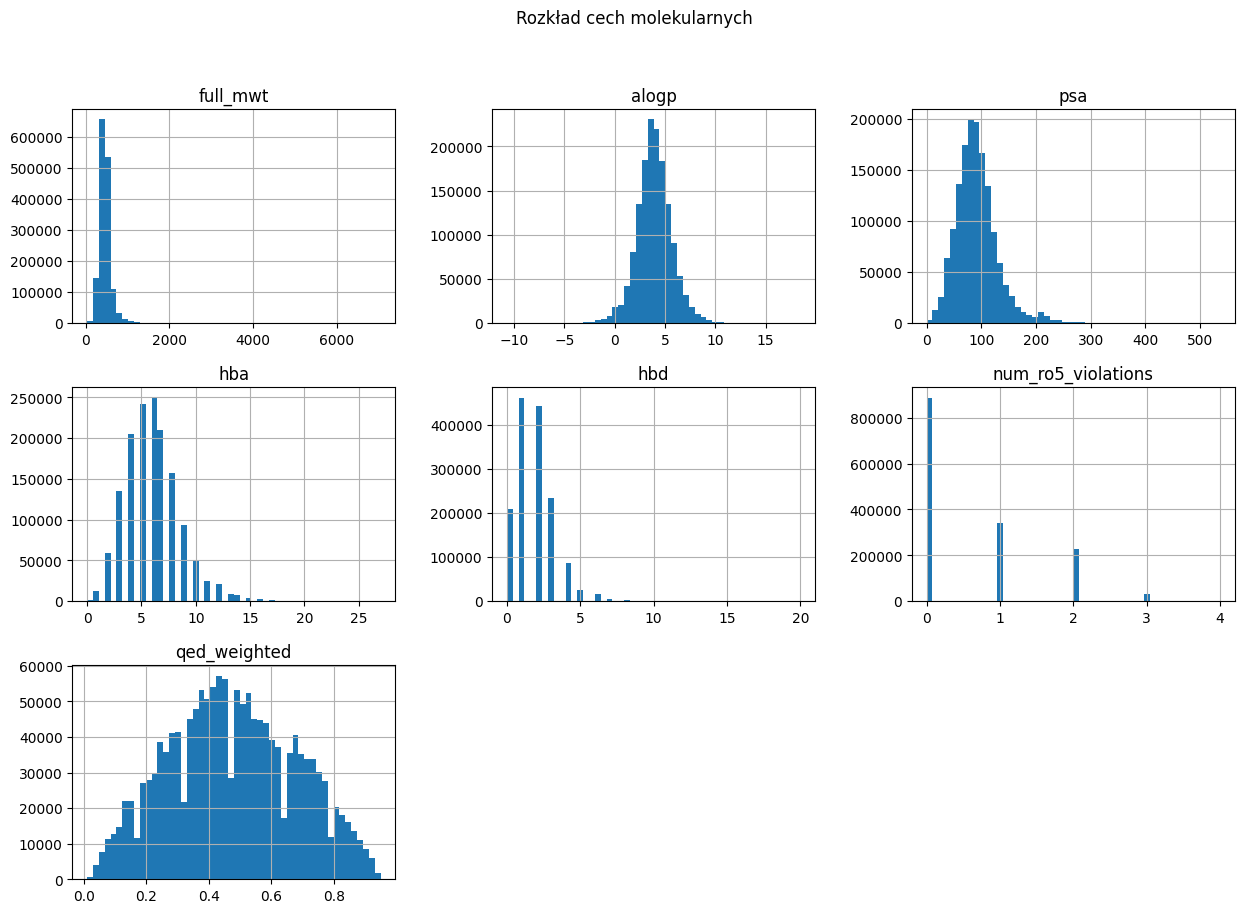

In [34]:
# Lista deskryptorów
features = ['full_mwt', 'alogp', 'psa', 'hba', 'hbd', 'num_ro5_violations', 'qed_weighted']

# Histogramy cech
df[features].hist(bins=50, figsize=(15,10))
plt.suptitle("Rozkład cech molekularnych")
plt.show()

## Korelacje

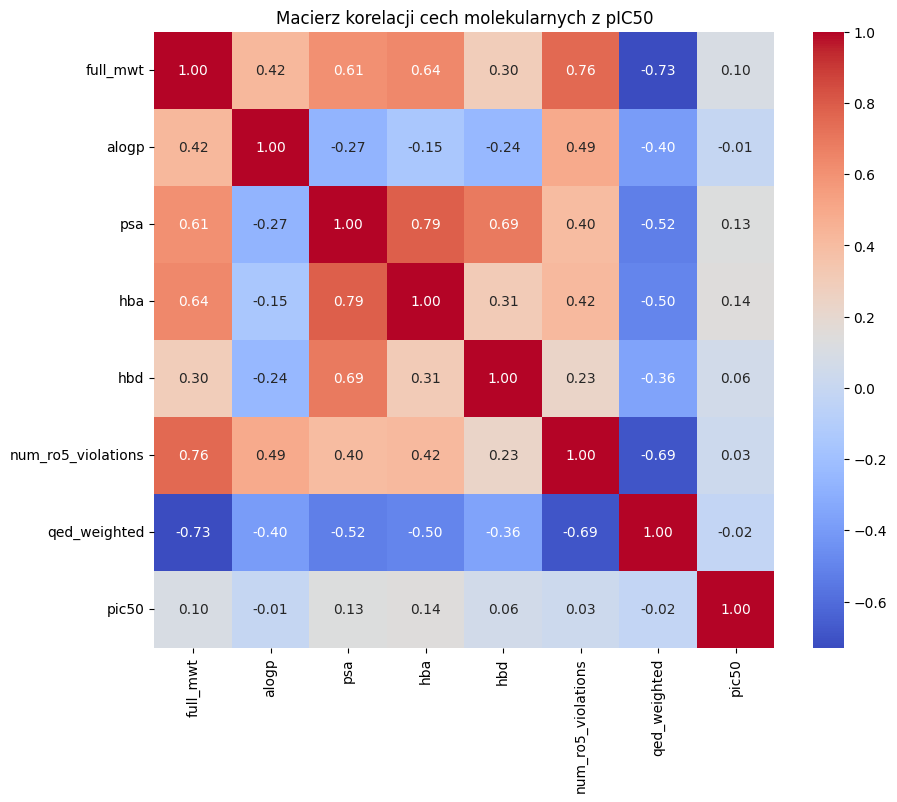

In [35]:
corr = df[features + ['pic50']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji cech molekularnych z pIC50")
plt.show()

## Z czego wynikają "piki" na rozkładzie po konwersji?

Wcześniej robiliśmy histogram na danych zagregowanych, a teraz wzieliśmy surowe pomiary + dodatkowa konwersja, jest dużo wartości "okrągłych"

In [36]:
counts = all_units.groupby(['standard_units', 'standard_value']).size().reset_index(name='n_records')
counts.sort_values('n_records', ascending=False).head(20)

,standard_units,standard_value,n_records
23858,nM,550.0,10899
29547,nM,1000.0,10569
12969,nM,100.0,10306
10279,nM,55.0,9758
6409,nM,10.0,8767
56464,nM,10000.0,8588
3470,nM,2.0,8485
2834,nM,1.0,7879
19009,nM,300.0,7638
3985,nM,3.0,7596


# Outliery

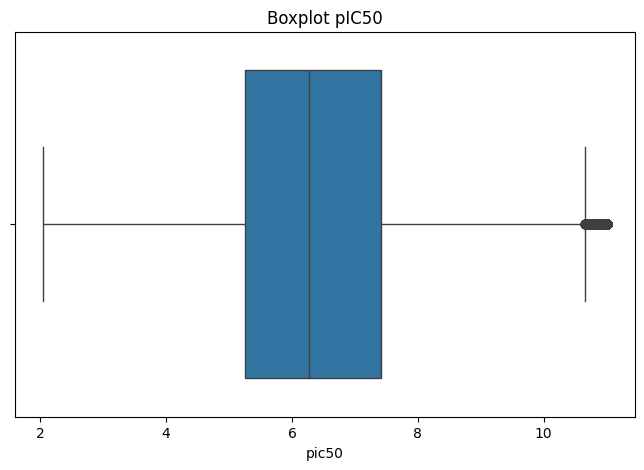

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['pic50'])
plt.title("Boxplot pIC50")
plt.show()

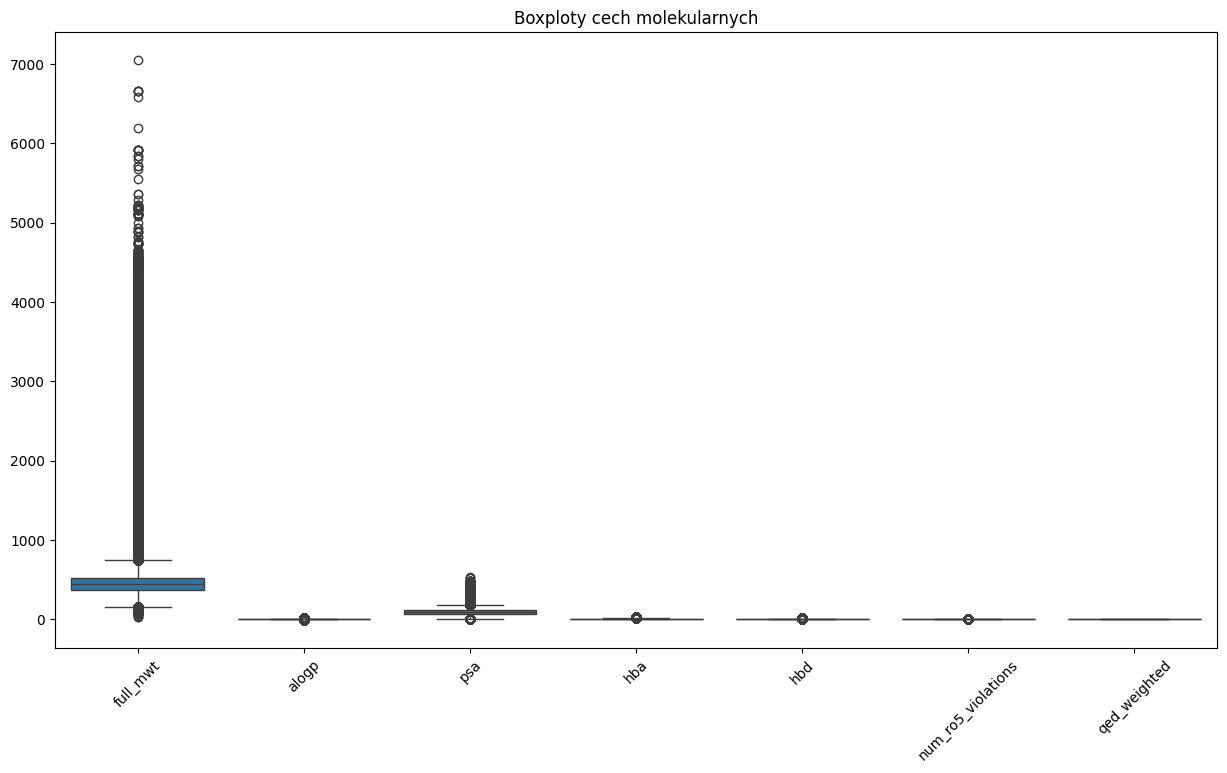

In [38]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[features])
plt.xticks(rotation=45)
plt.title("Boxploty cech molekularnych")
plt.show()

# Obsługa braków

In [39]:
features = ['full_mwt', 'alogp', 'psa', 'hba', 'hbd', 'num_ro5_violations', 'qed_weighted']

df_ml = df.dropna(subset=features + ['pic50'])

print(f"Liczba rekordów po usunięciu braków: {df_ml.shape[0]}")

Liczba rekordów po usunięciu braków: 1488029


In [40]:
missing_pct = df.isna().sum()/len(df)*100
print(missing_pct.sort_values(ascending=False))

data_validity_comment    100.000000
pref_name                 90.389804
activity_comment          75.070990
hbd                        2.483222
alogp                      2.483222
psa                        2.483222
hba                        2.483222
qed_weighted               2.483222
num_ro5_violations         2.483222
standard_value             0.000000
standard_units             0.000000
molregno_x                 0.000000
assay_id                   0.000000
activity_id                0.000000
canonical_smiles           0.000000
standard_type              0.000000
pic50                      0.000000
molregno_y                 0.000000
src_id                     0.000000
relation                   0.000000
pchembl_value              0.000000
ic50_molar                 0.000000
full_mwt                   0.000000
dtype: float64


### Po usunięciu

In [41]:
missing_pct_af = df_ml.isna().sum()/len(df_ml)*100
print(missing_pct_af.sort_values(ascending=False))

data_validity_comment    100.000000
pref_name                 90.351801
activity_comment          74.612793
canonical_smiles           0.000000
activity_id                0.000000
assay_id                   0.000000
molregno_x                 0.000000
standard_type              0.000000
standard_units             0.000000
standard_value             0.000000
pchembl_value              0.000000
src_id                     0.000000
ic50_molar                 0.000000
pic50                      0.000000
relation                   0.000000
molregno_y                 0.000000
full_mwt                   0.000000
alogp                      0.000000
psa                        0.000000
hba                        0.000000
hbd                        0.000000
num_ro5_violations         0.000000
qed_weighted               0.000000
dtype: float64


### Co zrobić z cechami, z czego wynikają te braki?

hbd
alogp
psa
hba
qed_weighted
num_ro5_violations

Na razie usunęliśmy, może da się uzupełnić?

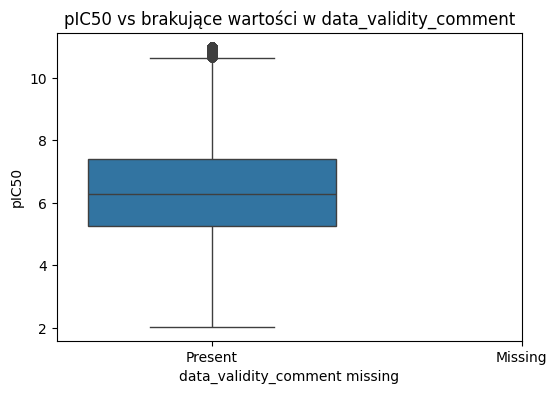

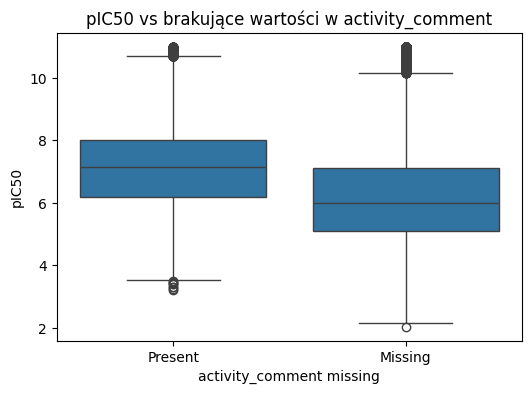

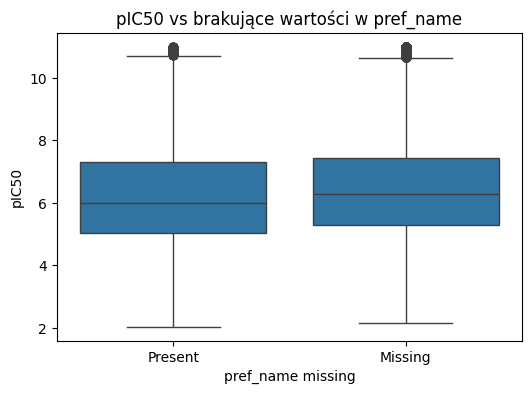

In [42]:
cols_with_na = df_ml.columns[df_ml.isna().any()].tolist()

for col in cols_with_na:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_ml[col].isna(), y=df_ml['pic50'])
    plt.xticks([0,1], ['Present', 'Missing'])
    plt.xlabel(f"{col} missing")
    plt.ylabel("pIC50")
    plt.title(f"pIC50 vs brakujące wartości w {col}")
    plt.show()

# Standaryzacja

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[features])

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print(X_scaled_df)

         full_mwt     alogp       psa       hba       hbd  num_ro5_violations  \
0       -0.716579 -1.445500 -0.697337 -0.430036 -0.596236           -0.728787   
1        2.446585 -3.073661  4.755166  5.149495  4.450294            2.930816   
2       -0.458318 -0.230113 -0.053771  0.367040 -0.596236           -0.728787   
3       -1.810102 -1.015528 -1.239916 -1.227112 -1.317168           -0.728787   
4       -1.810102 -1.015528 -1.239916 -1.227112 -1.317168           -0.728787   
...           ...       ...       ...       ...       ...                 ...   
1488024 -0.482737 -0.912335  0.242574  0.367040  0.124697           -0.728787   
1488025  2.173851  1.128599  1.365126  1.164116  1.566563            1.710948   
1488026  0.221697 -0.149851  0.480668  0.765578 -0.596236           -0.728787   
1488027  0.689380  0.268655  1.030116  1.164116  0.124697            0.491081   
1488028 -0.280512 -1.439767  0.276660  0.367040  0.845630           -0.728787   

         qed_weighted  
0  

# Tworzenie nowych cech

- logP_over_PSA (alogp / (psa * 1e-6)) - stosunek lipofilowości do polarnej powierzchni cząsteczki
    - interpretacja:
        - wysoki stosunek, łatwiej przechodzi bez błony biologiczne
        - niski stosunek, trudności z przenikamiem błon
- HBA_HBD_ratio (hba / (hbd + 1e-6)) - stosunek liczby akceptorów wiązań wodorowych do liczby donorów
    - interpetacja:
        - wysoki stosunek, cząsteczka może mieć inną charakterystykę rozpuszczalności i wiążań z białkami
        - niski stosunek, więcej donorów niż akceptorów
        - pozwala na uchwycenie równowagi donor/akceptor
- HBA_HBD_sum ( hba + hbd ) - całkowita liczba grup zdolnych do tworzenia wiązań wodorowych w cząsteczce
    - interpretacja:
        - wysoka wartość, czyli więcej możliwośći tworzenia wiązań wodorowych
        - niska wartość, czyli cząsteczka bardziej apolarna
        - jest to prosty wskaźnik potecjału polarnego cząsteczki


In [44]:
df_ml['logP_over_PSA'] = df_ml['alogp'] / (df_ml['psa'] + 1e-6) 
df_ml['HBA_HBD_ratio'] = df_ml['hba'] / (df_ml['hbd'] + 1e-6)
df_ml['HBA_HBD_sum'] = df_ml['hba'] + df_ml['hbd']

/tmp/ipykernel_4999/666951345.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml['logP_over_PSA'] = df_ml['alogp'] / (df_ml['psa'] + 1e-6)
/tmp/ipykernel_4999/666951345.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml['HBA_HBD_ratio'] = df_ml['hba'] / (df_ml['hbd'] + 1e-6)
/tmp/ipykernel_4999/666951345.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

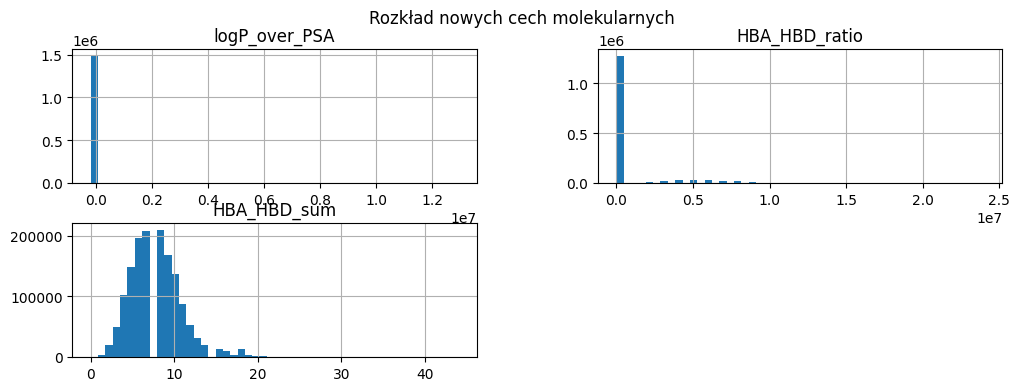

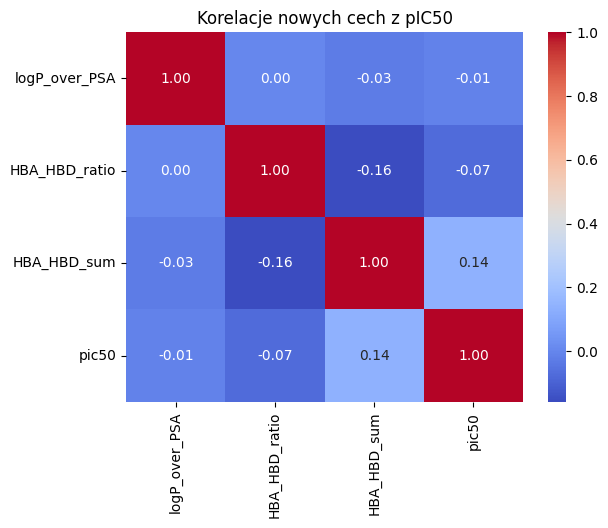

In [45]:
new_features = ['logP_over_PSA', 'HBA_HBD_ratio', 'HBA_HBD_sum']
df_ml[new_features].hist(bins=50, figsize=(12,4))
plt.suptitle("Rozkład nowych cech molekularnych")
plt.show()

sns.heatmap(df_ml[new_features + ['pic50']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelacje nowych cech z pIC50")
plt.show()

## Ile molekuł nie ma SMILES?

In [46]:
missing_smiles = df_ml['canonical_smiles'].isna().sum()

empty_smiles = (df_ml['canonical_smiles'] == '').sum()

total_missing = missing_smiles + empty_smiles

print(f"Liczba rekordów bez SMILES: {total_missing}")
print(f"- brakujące (NaN): {missing_smiles}")
print(f"- puste stringi: {empty_smiles}")

print(f"Procent wszystkich rekordów: {100 * total_missing / len(df_ml):.2f}%")

Liczba rekordów bez SMILES: 0
- brakujące (NaN): 0
- puste stringi: 0
Procent wszystkich rekordów: 0.00%


# Chemiczna różnorodność / błędy strukturalne

In [49]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import pandas as pd

# safe Mol conversion
def safe_mol(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None

# safe scaffold extraction
def get_scaffold(smiles):
    mol = safe_mol(smiles)
    if mol is None:
        return None
    try:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

def parallel_apply(func, series, n_cores=4):
    with Pool(n_cores) as pool:
        results = list(tqdm(pool.imap(func, series), total=len(series)))
    return results

df_ml['scaffold'] = parallel_apply(get_scaffold, df_ml['canonical_smiles'], n_cores=4)

valid_scaffolds = df_ml['scaffold'].notna().sum()
invalid_scaffolds = df_ml['scaffold'].isna().sum()

print(f"Valid scaffolds: {valid_scaffolds}")
print(f"Invalid or missing scaffolds: {invalid_scaffolds}")

100%|██████████| 1488029/1488029 [05:08<00:00, 4818.65it/s]


Valid scaffolds: 1488023
Invalid or missing scaffolds: 6


/tmp/ipykernel_4999/1642774352.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml['scaffold'] = parallel_apply(get_scaffold, df_ml['canonical_smiles'], n_cores=4)


## Zapis do parquet

In [50]:
df_ml.to_parquet("./parquets/df_ml_with_scaffold.parquet", engine="fastparquet", index=False)

## Lista błędnie strukturalnych cząsteczek

In [51]:
invalid_smiles_df = df_ml[df_ml['scaffold'].isna()]

print(f"Liczba błędnych cząsteczek: {len(invalid_smiles_df)}")

invalid_smiles = invalid_smiles_df['canonical_smiles'].unique()
print(f"Liczba unikalnych błędnych SMILES: {len(invalid_smiles)}")

invalid_smiles_df[['canonical_smiles', 'activity_id', 'standard_value']].head(10)

Liczba błędnych cząsteczek: 6
Liczba unikalnych błędnych SMILES: 6


,canonical_smiles,activity_id,standard_value
33803,Cc1ccc2ccc3ccc(C)nc3c2n1.F[PH](F)(F)(F)(F)F,24419222,20000.0
726606,Cc1cnc2c(ccc3c(C)c(C)cnc32)c1C.F[PH](F)(F)(F)(F)F,24419226,32000.0
1108775,F[PH](F)(F)(F)(F)F.O=[N+]([O-])c1cc2cccnc2c2nc...,24419227,32000.0
1181286,F[PH](F)(F)(F)(F)F.c1cnc2c(c1)ccc1cccnc12,24419223,28000.0
1472239,Clc1ccc2ccc3cccnc3c2n1.F[PH](F)(F)(F)(F)F,24419224,32000.0
1514845,F[PH](F)(F)(F)(F)F.Nc1cc2cccnc2c2ncccc12,24419228,32000.0


## Usunięcie błędnych cząsteczek

In [52]:
df_ml = pd.read_parquet("./parquets/df_ml_with_scaffold.parquet", engine="fastparquet")

df_ml_clean = df_ml[df_ml['scaffold'].notna()].copy()

print(f"Rekordy po usunięciu niepoprawnych scaffoldów: {len(df_ml_clean)}")

Rekordy po usunięciu niepoprawnych scaffoldów: 1488023


In [53]:
total_records = len(df_ml)

invalid_records = df_ml['scaffold'].isna().sum()

df_ml_clean = df_ml[df_ml['scaffold'].notna()].copy()
remaining_records = len(df_ml_clean)

print(f"Liczba wszystkich rekordów: {total_records}")
print(f"Liczba rekordów z błędną cząsteczką (scaffold NaN): {invalid_records}")
print(f"Liczba rekordów po usunięciu błędnych: {remaining_records}")
print(f"Procent usuniętych rekordów: {100 * invalid_records / total_records:.2f}%")

Liczba wszystkich rekordów: 1488029
Liczba rekordów z błędną cząsteczką (scaffold NaN): 6
Liczba rekordów po usunięciu błędnych: 1488023
Procent usuniętych rekordów: 0.00%


# Ocena ważności cech

Ważność cech:
psa                   0.270152
logP_over_PSA         0.208311
alogp                 0.186018
qed_weighted          0.171373
HBA_HBD_ratio         0.055052
HBA_HBD_sum           0.046679
hba                   0.030219
hbd                   0.018363
num_ro5_violations    0.013833
dtype: float64


/tmp/ipykernel_4999/2104904225.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


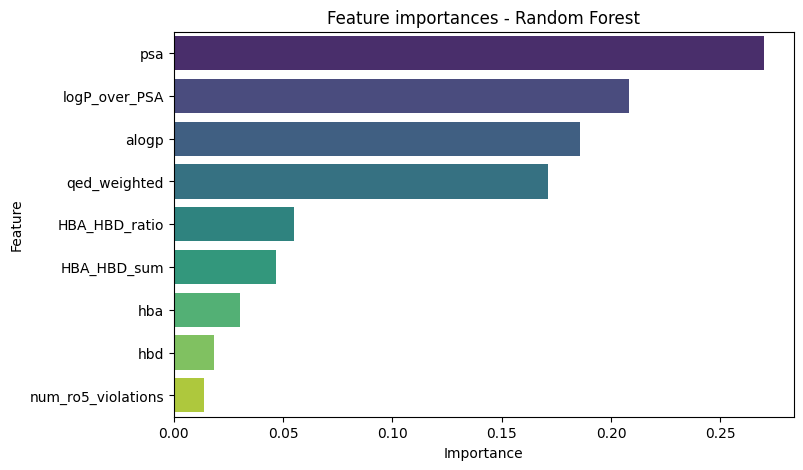

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_ml_clean['logP_over_PSA'] = df_ml_clean['alogp'] / (df_ml_clean['psa'] + 1e-6)
df_ml_clean['HBA_HBD_ratio'] = df_ml_clean['hba'] / (df_ml_clean['hbd'] + 1e-6)
df_ml_clean['HBA_HBD_sum'] = df_ml_clean['hba'] + df_ml_clean['hbd']

features = ['alogp','psa','hba','hbd','num_ro5_violations','qed_weighted',
            'logP_over_PSA','HBA_HBD_ratio','HBA_HBD_sum']

sample_df = df_ml_clean.sample(n=200_000, random_state=42)

X = sample_df[features]
y = sample_df['pic50']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("Ważność cech:")
print(importances)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Podział na train/test

In [55]:
from sklearn.model_selection import train_test_split

X = df_ml[features + ['logP_over_PSA', 'HBA_HBD_ratio', 'HBA_HBD_sum']]  # wszystkie cechy
y = df_ml['pic50']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (1190423, 12)
Rozmiar zbioru testowego: (297606, 12)


# Podsumowamie z analizy

#### Załadowanie danych:

około 1,5 mln rekordów IC50 po oczyszczeniu z błędnych struktur (scaffold NaN) pozostało 1 488 023 rekordów,
liczba unikalnych cząsteczek: 663 139.

#### Statystyki podstawowe:
pIC50: logarytmowana wartość IC50 w molach
Średnia liczba assay/compound: około mediany ~3–4.
Większość cech molekularnych (alogp, psa, hba, hbd, qed_weighted) ma drobne braki (~2,5%).
pref_name i activity_comment mają duże braki (75–90%), więc nie nadają się bezpośrednio do ML.

#### Braki i anomalie
1,31% rekordów nie udało się przekonwertować do pIC50, usunięto.
6 rekordów z błędnym scaffold, usunięto.

#### Nowe cechy
logP_over_PSA = alogP / (PSA + 1e-6)
HBA_HBD_ratio = HBA / (HBD + 1e-6)
HBA_HBD_sum = HBA + HBD
Te cechy opisują relacje między polarnością, hydrofilowością i liczbą donorów/akceptorów wodoru, co jest ważne dla aktywności biologicznej.

#### Kluczowe obserwacje

Braki w cechach molekularnych są niewielkie (~2,5%), a brakujące scaffolds praktycznie zerowe.


#### Ważność cech

| Cecha                  | Importance | Co to oznacza                                                                                               |
| ---------------------- | ---------- | ----------------------------------------------------------------------------------------------------------- |
| **psa**                | 0.27       | Polar Surface Area – powierzchnia polarna cząsteczki jest **najbardziej wpływowa na pIC50** w Twoim modelu. |
| **logP_over_PSA**      | 0.21       | Stosunek logP do PSA – pokazuje równowagę między lipofilowością a polarnością, też silnie wpływa.           |
| **alogp**              | 0.19       | LogP (lipofilowość) – istotna dla biodostępności i rozpuszczalności.                                        |
| **qed_weighted**       | 0.17       | Drug-likeness – waga cechy w modelu jest spora, co ma sens chemicznie.                                      |
| **HBA_HBD_ratio**      | 0.055      | Stosunek akceptorów/wodorodonorów – ma umiarkowany wpływ.                                                   |
| **HBA_HBD_sum**        | 0.047      | Suma akceptorów i donorów – niewielki wpływ.                                                                |
| **hba**                | 0.03       | Liczba akceptorów H – mały wpływ.                                                                           |
| **hbd**                | 0.018      | Liczba donorów H – bardzo mały wpływ.                                                                       |
| **num_ro5_violations** | 0.014      | Naruszenia reguły Lipinskiego – prawie nie wpływa na model.                                                 |
